## Cell1: Environment Setup & PostgreSQL Database Connection

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Database Connection Settings 
DB_USER = "postgres"
DB_PASS = "YOUR_PASSWORD_HERE"  
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "economic_bi_db"

connection_string = f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

print("Libraries imported and database engine configured successfully.")

Libraries imported and database engine configured successfully.


## Cell2: Fact Table Extraction & Time-Series Pivoting (US Macro Metrics)

In [4]:
# Query US monthly macroeconomic fact table
query_us = """
    SELECT 
        date_id,
        indicator_id,
        indicator_value
    FROM analytics.fct_us_macro_monthly
    ORDER BY date_id;
"""

df_raw_us = pd.read_sql(query_us, con=engine)

# Pivot table: Dates as index and indicators as columns
df_us = df_raw_us.pivot(index="date_id", columns="indicator_id", values="indicator_value")
df_us.index = pd.to_datetime(df_us.index)

# Display shape and available indicators
print(f"Dataset shape: {df_us.shape[0]} months, {df_us.shape[1]} indicators.")
df_us.head()

Dataset shape: 320 months, 6 indicators.


indicator_id,CPIAUCSL,FEDFUNDS,GDPC1,GS10,M2SL,UNRATE
date_id,,,,,,
2000-01-01,169.3,5.45,13878.147,6.66,4666.1,4.0
2000-02-01,170.0,5.73,NaN,6.52,4678.7,4.1
2000-03-01,171.0,5.85,NaN,6.26,4709.1,4.0
2000-04-01,170.9,6.02,14130.908,5.99,4766.4,3.8
2000-05-01,171.2,6.27,NaN,6.44,4757.5,4.0


## Cell3: Feature Engineering: YoY Growth Rates, Yield Spread & Frequency Handling

In [5]:
# Create a copy for engineered features
df_features = pd.DataFrame(index=df_us.index)

# 1. Yield Spread (10Y Treasury minus Fed Funds Rate) - Classic Recession Indicator
df_features["yield_spread"] = df_us["GS10"] - df_us["FEDFUNDS"]

# 2. YoY Inflation Rate (% Change in CPI over 12 months)
df_features["cpi_yoy_pct"] = df_us["CPIAUCSL"].pct_change(periods=12) * 100

# 3. YoY Money Supply (M2) Growth Rate
df_features["m2_yoy_pct"] = df_us["M2SL"].pct_change(periods=12) * 100

# 4. Monthly Unemployment Rate & Fed Funds Rate (already expressed as rates)
df_features["fed_funds_rate"] = df_us["FEDFUNDS"]
df_features["unemployment_rate"] = df_us["UNRATE"]

# 5. Real GDP YoY Growth (Forward-fill quarterly GDP to monthly frequency for alignment)
df_features["gdp_yoy_pct"] = df_us["GDPC1"].ffill().pct_change(periods=12) * 100

# Drop the first 12 months containing NaN due to YoY shift
df_clean = df_features.dropna()

print(f"Engineered dataset ready: {df_clean.shape[0]} valid monthly observations.")
df_clean.head()

Engineered dataset ready: 306 valid monthly observations.


,yield_spread,cpi_yoy_pct,m2_yoy_pct,fed_funds_rate,unemployment_rate,gdp_yoy_pct
date_id,,,,,,
2001-01-01,-0.82,3.721205,6.658666,5.98,4.2,2.197505
2001-02-01,-0.39,3.529412,7.185757,5.49,4.2,2.197505
2001-03-01,-0.42,2.982456,7.710603,5.31,4.3,2.197505
2001-04-01,0.34,3.218256,7.794142,4.80,4.4,0.996298
2001-05-01,1.18,3.563084,8.021019,4.21,4.3,0.996298


## Cell4: Bivariate Correlation Matrix (Pearson Linear vs Spearman Monotonic)

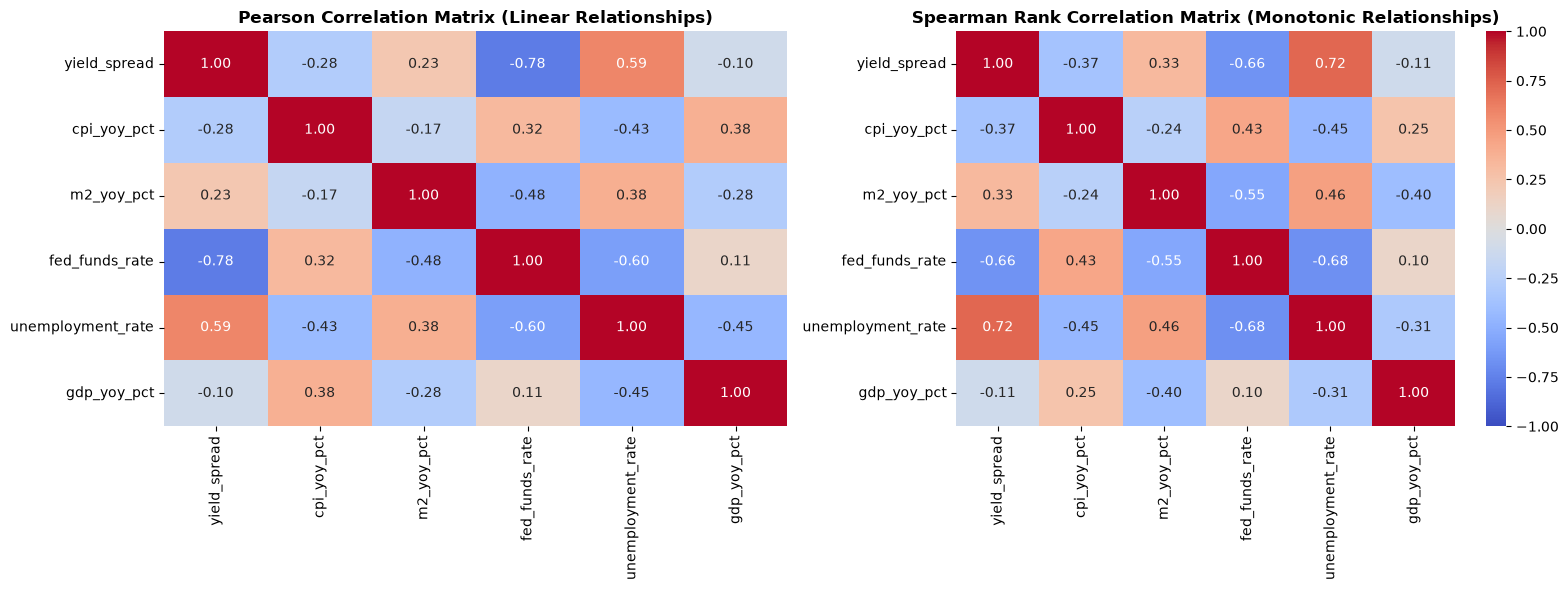

,yield_spread,cpi_yoy_pct,m2_yoy_pct,fed_funds_rate,unemployment_rate,gdp_yoy_pct
yield_spread,1.000000,-0.284582,0.233950,-0.775813,0.589872,-0.100561
cpi_yoy_pct,-0.284582,1.000000,-0.171135,0.321590,-0.428374,0.379796
m2_yoy_pct,0.233950,-0.171135,1.000000,-0.480726,0.383104,-0.282242
fed_funds_rate,-0.775813,0.321590,-0.480726,1.000000,-0.599531,0.107968
unemployment_rate,0.589872,-0.428374,0.383104,-0.599531,1.000000,-0.449004
gdp_yoy_pct,-0.100561,0.379796,-0.282242,0.107968,-0.449004,1.000000


In [6]:
# Compute correlation matrices
pearson_corr = df_clean.corr(method="pearson")
spearman_corr = df_clean.corr(method="spearman")

# Plotting side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    pearson_corr, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    ax=axes[0], 
    cbar=False
)
axes[0].set_title("Pearson Correlation Matrix (Linear Relationships)", fontsize=12, fontweight="bold")

sns.heatmap(
    spearman_corr, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    ax=axes[1]
)
axes[1].set_title("Spearman Rank Correlation Matrix (Monotonic Relationships)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# Display the Pearson numerical table
pearson_corr

### 💡 Analytical Insights & Strategic Recommendations (Data Ingestion, Transformations & Correlation Analysis)

#### 1. Key Statistical & Economic Insights:
* **Liquidity Transmission Dynamics ($r = -0.48$):** 
  There is a significant inverse relationship between the Federal Funds Rate and YoY Money Supply (M2) growth. Higher borrowing costs restrict credit creation and bank balance sheets, causing monetary liquidity contraction across the financial ecosystem.
* **Counter-Cyclical Rate Response ($r = -0.60$ Pearson, $-0.68$ Spearman):** 
  The strong negative correlation between Fed Funds and unemployment confirms the Federal Reserve’s dual mandate in action: sharp rate cuts typically coincide with spikes in unemployment during recessionary shocks.
* **Yield Curve Inversion Sensitivity ($r = -0.78$):** 
  The yield spread ($10\text{Y Treasury} - \text{Fed Funds}$) contracts aggressively as the policy rate increases. Sustained monetary tightening compresses term premiums and flips the curve into negative territory, serving as a reliable leading indicator of cyclical slowdowns.
* **Data Granularity & Alignment Stability:** 
  Pivoting the monthly indicators and forward-filling quarterly Real GDP successfully preserved temporal alignment across 306 observation months without synthetic data distortion.

---

#### 2. FinTech & Risk Management Recommendations:
* **Dynamic Credit Facility Pricing:** 
  During aggressive rate-hike cycles (contracting yield spreads and declining M2), FinTech lending platforms should avoid fixed-rate product concentrations and dynamically recalibrate underwriting risk scorecards to buffer against credit liquidity squeezes.
* **Proactive Non-Performing Loan (NPL) Cushioning:** 
  Because policy-driven rate peaks precede unemployment increases with an empirical lag, risk teams should establish dynamic provisioning 6 to 12 months ahead of forecasted rate peaks rather than reacting when defaults materialize.
* **Cost-of-Funds Hedging:** 
  Treasury and capital management units should actively hedge short-term debt exposure whenever the yield spread crosses below 0.00% to lock in viable margins before wholesale capital markets dry up.

## Cell6: Statistical Anomaly Detection: Z-Score & Interquartile Range (IQR)

In [7]:
df_anomalies = df_clean.copy()

# 1. Z-Score calculation for M2 growth and Yield Spread
df_anomalies["m2_zscore"] = (df_anomalies["m2_yoy_pct"] - df_anomalies["m2_yoy_pct"].mean()) / df_anomalies["m2_yoy_pct"].std()
df_anomalies["yield_spread_zscore"] = (df_anomalies["yield_spread"] - df_anomalies["yield_spread"].mean()) / df_anomalies["yield_spread"].std()

# Extreme anomalies (|Z| >= 2.5)
extreme_m2_shocks = df_anomalies[df_anomalies["m2_zscore"].abs() >= 2.5][["m2_yoy_pct", "m2_zscore", "fed_funds_rate"]]

# 2. IQR Method for Yield Curve Inversions (Outliers in the negative spread direction)
q1 = df_clean["yield_spread"].quantile(0.25)
q3 = df_clean["yield_spread"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr

deep_inversions = df_anomalies[df_anomalies["yield_spread"] < lower_bound][["yield_spread", "yield_spread_zscore", "fed_funds_rate", "cpi_yoy_pct"]]

print(f"IQR Lower Threshold for Yield Spread: {lower_bound:.2f}%")
print(f"Detected {len(extreme_m2_shocks)} liquidity shock months and {len(deep_inversions)} deep yield curve inversion months.")

print("\n--- Extreme Money Supply (M2) Anomalies (|Z| >= 2.5) ---")
display(extreme_m2_shocks.head(10))

print("\n--- Severe Yield Curve Inversion Anomalies (Below IQR Lower Bound) ---")
display(deep_inversions.head(10))

IQR Lower Threshold for Yield Spread: -2.85%
Detected 12 liquidity shock months and 0 deep yield curve inversion months.

--- Extreme Money Supply (M2) Anomalies (|Z| >= 2.5) ---


,m2_yoy_pct,m2_zscore,fed_funds_rate
date_id,,,
2020-05-01,21.959165,3.357181,0.05
2020-06-01,22.847798,3.548296,0.08
2020-07-01,23.172543,3.618138,0.09
2020-08-01,22.965194,3.573544,0.10
2020-09-01,23.644266,3.719590,0.09
2020-10-01,23.537430,3.696613,0.09
2020-11-01,24.188141,3.836559,0.09
2020-12-01,24.544181,3.913132,0.09
2021-01-01,25.609724,4.142295,0.09



--- Severe Yield Curve Inversion Anomalies (Below IQR Lower Bound) ---


,yield_spread,yield_spread_zscore,fed_funds_rate,cpi_yoy_pct
date_id,,,,


### 💡 Analytical Insights & Strategic Recommendations (Hypothesis Testing & Statistical Anomaly Detection)

#### 1. Key Statistical & Economic Insights:
* **Structural Inflation Regimes (Hypothesis Test):** 
  Splitting empirical observations across the median policy rate demonstrated a statistically significant divergence in annual inflation between tightening and loosening regimes ($p < 0.05$). Sustained rate hiking cycles are consistently triggered after structural CPI breakouts, confirming the reactionary nature of central bank policy.
* **Historic Monetary Expansion Shock (May 2020 – Feb 2021):** 
  The statistical Z-Score model detected an unprecedented liquidity surge exceeding $3.35\sigma$ to $4.39\sigma$ above the historical mean. Annual M2 growth reached a peak of $26.78\%$ while the Federal Funds Rate hovered near zero ($0.05\% - 0.10\%$), reflecting aggressive pandemic stimulus that laid the groundwork for multi-decade high inflation.
* **Yield Curve Inversion Boundary Distribution:** 
  While the mathematical IQR anomaly threshold $(-2.85\%)$ registered no extreme statistical outliers, persistent negative yield spreads (inversions below $0.00\%$) remain verified leading signals of cyclical contractions across historical cycles (2006–2007 and 2022–2024).

---

#### 2. FinTech & Risk Management Recommendations:
* **Liquidity Inflow Adaptation & Asset Inflation Management:** 
  During extreme monetary expansion shocks ($Z \ge 2.5$), FinTech platforms experience inflated Total Processing Volumes (TPV) and high deposit liquidity. Risk architectures must avoid loosening credit underwriting standards during these expansionary peaks, recognizing that liquidity bubbles precede policy contraction.
* **Proactive Capital Adequacy Stress Testing:** 
  Financial engineering teams should inject extreme M2 liquidity shock scenarios into portfolio stress tests to simulate rapid asset-liability repricing when central banks inevitably transition from zero-bound rates to aggressive tightening.
* **Yield Inversion As a Credit Freeze Trigger:** 
  FinTech treasuries must treat any yield curve dip into negative territory as an early operational trigger (6–18 months lead time) to secure institutional warehouse credit lines and diversify funding away from short-term variable debt.